In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('zomato.csv')

In [4]:
df.shape

(51717, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [6]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [7]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [8]:
#filter the columns required for analysis
col_used=['name','online_order','book_table','rate','votes','location','rest_type','cuisines','approx_cost(for two people)','listed_in(type)']
df1=df[col_used]

In [9]:
df1.head(3)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet


In [10]:
df1.shape

(51717, 10)

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         51717 non-null  str  
 1   online_order                 51717 non-null  str  
 2   book_table                   51717 non-null  str  
 3   rate                         43942 non-null  str  
 4   votes                        51717 non-null  int64
 5   location                     51696 non-null  str  
 6   rest_type                    51490 non-null  str  
 7   cuisines                     51672 non-null  str  
 8   approx_cost(for two people)  51371 non-null  str  
 9   listed_in(type)              51717 non-null  str  
dtypes: int64(1), str(9)
memory usage: 3.9 MB


In [12]:
df1.rate.unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',      nan,  '2.6/5', '3.8 /5',
  '3.4/5',  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',
  '2.3/5', '3.4 /5',      '-', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5',
 '4.0 /5', '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
 '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5',
 '4.4 /5',  '4.9/5',  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5',
 '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5', '2.2 /5',
 '2.0 /5', '1.8 /5']
Length: 65, dtype: str

In [13]:
#rate column is given as str, we need to change it to float because ratings can either be numeric or decimal
df1['rate']=df1['rate'].replace('NEW',np.nan)


In [14]:

df1['rate']=df1['rate'].replace('-',np.nan)

In [15]:
df1['rate']=df1['rate'].str.split('/')

In [16]:
df1['rate']=df1['rate'].str[0]

In [17]:
df1['rate']=pd.to_numeric(df1['rate'])

In [18]:
df1.head(3)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet


In [19]:
df1['rate'].dtype


dtype('float64')

In [20]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  str    
 1   online_order                 51717 non-null  str    
 2   book_table                   51717 non-null  str    
 3   rate                         41665 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  str    
 6   rest_type                    51490 non-null  str    
 7   cuisines                     51672 non-null  str    
 8   approx_cost(for two people)  51371 non-null  str    
 9   listed_in(type)              51717 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.9 MB


In [21]:
df1['rate'].isna().sum()

np.int64(10052)

In [22]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
rate,41665.0,3.700449,0.440513,1.8,3.4,3.7,4.0,4.9
votes,51717.0,283.697527,803.838853,0.0,7.0,41.0,198.0,16832.0


In [23]:
rate_median=df1['rate'].median()

In [24]:
df1['rate']=df1['rate'].replace(np.nan,rate_median)

In [25]:
df1['rate'].isna().sum()

np.int64(0)

In [26]:
df1['approx_cost(for two people)'].isna().sum()

np.int64(346)

In [27]:
df1['approx_cost(for two people)'].unique()

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000', '1,500', '1,300',   '199',    '80',
 '1,100',   '160', '1,600',   '230',   '130',    '50',   '190', '1,700',
     nan, '1,400',   '180', '1,350', '2,200', '2,000', '1,800', '1,900',
   '330', '2,500', '2,100', '3,000', '2,800', '3,400',    '40', '1,250',
 '3,500', '4,000', '2,400', '2,600',   '120', '1,450',   '469',    '70',
 '3,200',    '60',   '560',   '240',   '360', '6,000', '1,050', '2,300',
 '4,100', '5,000', '3,700', '1,650', '2,700', '4,500',   '140']
Length: 71, dtype: str

In [28]:
df1['approx_cost(for two people)']=df1['approx_cost(for two people)'].str.replace(',','')

In [29]:
df1['approx_cost(for two people)']=pd.to_numeric(df1['approx_cost(for two people)'])

In [30]:
cost_median=df1['approx_cost(for two people)'].median()
df1['approx_cost(for two people)']=df1['approx_cost(for two people)'].fillna(cost_median)

In [31]:
df1['approx_cost(for two people)']=df1['approx_cost(for two people)'].astype(int)

In [32]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
rate,51717.0,3.700362,0.395391,1.8,3.5,3.7,3.9,4.9
votes,51717.0,283.697527,803.838853,0.0,7.0,41.0,198.0,16832.0
approx_cost(for two people),51717.0,554.391689,437.563723,40.0,300.0,400.0,650.0,6000.0


In [33]:
df1['location'].isna().sum()
df1=df1.dropna(subset=['location','cuisines'])

In [34]:
df1['cuisines'].isna().sum()

np.int64(0)

In [35]:
df1.isna().sum()

name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
location                         0
rest_type                      206
cuisines                         0
approx_cost(for two people)      0
listed_in(type)                  0
dtype: int64

In [36]:
df1=df1.drop_duplicates(keep='first')

In [37]:
df1.duplicated().sum()

np.int64(0)

In [38]:
df1.info()

<class 'pandas.DataFrame'>
Index: 31893 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         31893 non-null  str    
 1   online_order                 31893 non-null  str    
 2   book_table                   31893 non-null  str    
 3   rate                         31893 non-null  float64
 4   votes                        31893 non-null  int64  
 5   location                     31893 non-null  str    
 6   rest_type                    31775 non-null  str    
 7   cuisines                     31893 non-null  str    
 8   approx_cost(for two people)  31893 non-null  int64  
 9   listed_in(type)              31893 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 2.7 MB


In [39]:
df_rest=df1.copy()

In [40]:
df_rest['rest_type']=df_rest['rest_type'].str.split(',')

In [41]:
df_rest=df_rest.explode('rest_type')


In [42]:
df_rest['rest_type']=df_rest['rest_type'].str.strip()

In [43]:
df_rest['rest_type'].isna().sum()

np.int64(118)

In [44]:
df_rest['rest_type']=df_rest.groupby('location')['rest_type'].transform(lambda x:x.fillna(x.mode()[0])if not x.mode().empty else 'others')

In [45]:
df_rest.isna().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [46]:
df_rest.duplicated().sum()
df_rest=df_rest.drop_duplicates(keep='first')

In [47]:
df_rest.duplicated().sum()

np.int64(0)

In [48]:
df_cuisine=df1.copy()

In [49]:
df_cuisine['cuisines']=df_cuisine['cuisines'].str.split(',')

In [50]:
df_cuisine=df_cuisine.explode('cuisines')

In [51]:
df_cuisine['cuisines']=df_cuisine['cuisines'].str.strip()

In [52]:
df_cuisine['cuisines'].value_counts().head(15)

cuisines
North Indian    13294
Chinese          9637
South Indian     5096
Fast Food        4735
Continental      4132
Biryani          4109
Cafe             3555
Desserts         3487
Beverages        2922
Italian          2382
Bakery           1641
Street Food      1618
Pizza            1506
Burger           1460
Andhra           1238
Name: count, dtype: int64

In [53]:
df1.location.nunique()

93

In [54]:
df1[df1['location'].str.contains('Whitefield')]['location'].value_counts()

location
Whitefield                       1823
Varthur Main Road, Whitefield     100
ITPL Main Road, Whitefield         93
Name: count, dtype: int64

In [55]:
df1['location']=df1['location'].str.replace('Varthur Main Road, Whitefield','Whitefield')

In [56]:
df1['location']=df1['location'].str.replace('ITPL Main Road, Whitefield','Whitefield')

In [57]:
df1[df1['location'].str.contains('Whitefield')]['location'].value_counts()

location
Whitefield    2016
Name: count, dtype: int64

In [58]:
df1[df1['location'].str.startswith('Koramangala ')]['location'].value_counts()

location
Koramangala 5th Block    1426
Koramangala 4th Block     519
Koramangala 7th Block     511
Koramangala 6th Block     510
Koramangala 1st Block     438
Koramangala 8th Block     132
Koramangala 3rd Block     107
Koramangala 2nd Block      44
Name: count, dtype: int64

In [59]:
df1['listed_in(type)'].value_counts()

listed_in(type)
Delivery              14565
Dine-out              11837
Desserts               2249
Cafes                  1165
Drinks & nightlife      875
Buffet                  623
Pubs and bars           579
Name: count, dtype: int64

In [60]:
df_cuisine=df_cuisine.drop_duplicates(keep='first')

In [61]:
df_cuisine.duplicated().sum()

np.int64(0)

In [62]:
df1=df1.drop_duplicates(keep='first')

In [63]:
print("--"*20)
print("summary after datacleaning")
print("--"*20)
print(f"Raw Data: {df.shape}")
print(f"Clean Data: {df1.shape}")
print(f"Data after splitting rest_type df_rest: {df_rest.shape}")
print(f"Data after splitting cuisines df_cuisine: {df_cuisine.shape}")
print("---null checks---")
print(f"clean data {df1.isna().sum()}")
print(f"rest type data {df_rest.isna().sum()}")
print(f"cuisine data {df_cuisine.isna().sum()}")
print("---Dupliates checks---")
print(f"clean data {df1.duplicated().sum()}")
print(f"rest type data {df_rest.duplicated().sum()}")
print(f"cuisine data {df_cuisine.duplicated().sum()}")

----------------------------------------
summary after datacleaning
----------------------------------------
Raw Data: (51717, 17)
Clean Data: (31890, 10)
Data after splitting rest_type df_rest: (37183, 10)
Data after splitting cuisines df_cuisine: (81229, 10)
---null checks---
clean data name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
location                         0
rest_type                      118
cuisines                         0
approx_cost(for two people)      0
listed_in(type)                  0
dtype: int64
rest type data name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
dt

univariate analysis


In [64]:
df1.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)'],
      dtype='str')

In [65]:
#location wise restaurant counts -- supply (how many options)
location_supply=df1['location'].value_counts().head(20)

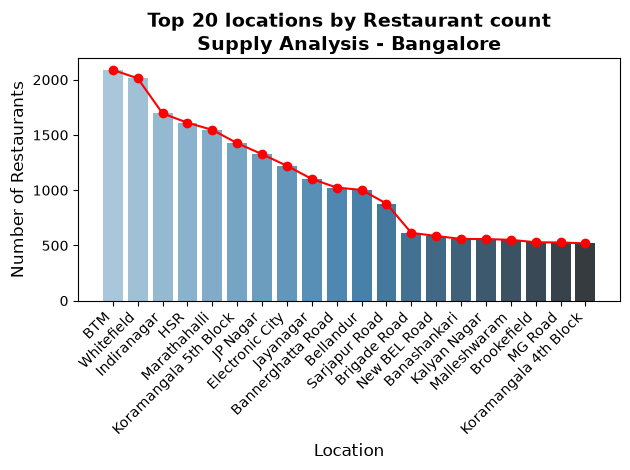

In [66]:
plt.Figure(figsize=(15,6))
sns.barplot(x=location_supply.index,y=location_supply.values,palette='Blues_d')
plt.title('Top 20 locations by Restaurant count\n' 'Supply Analysis - Bangalore',
          loc='center',fontsize=14,fontweight='bold')

plt.plot(location_supply.index,location_supply.values,marker='o',color='r')
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xlabel('Location', fontsize=12)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [67]:
# location wise restaurant demand-- 
# location wise restaurant voting helps in finding the demand
#how many people are engaging

location_demand=round(df1.groupby('location')['votes'].agg('mean').sort_values(ascending=False)).head(20)



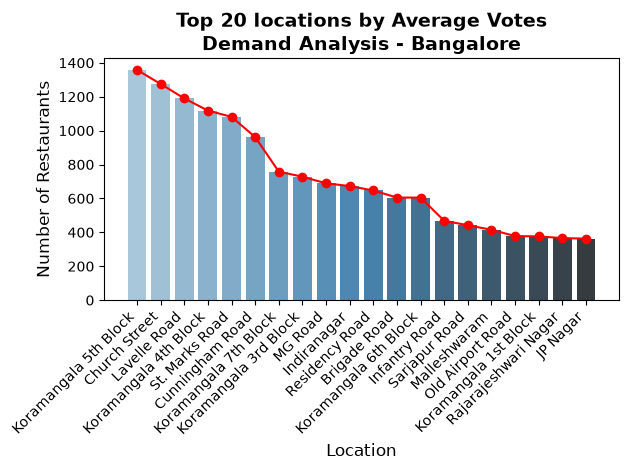

In [68]:
plt.Figure(figsize=(15,6))
sns.barplot(x=location_demand.index,y=location_demand.values,palette='Blues_d')
plt.title('Top 20 locations by Average Votes\n' 'Demand Analysis - Bangalore',
          loc='center',fontsize=14,fontweight='bold')

plt.plot(location_demand.index,location_demand.values,marker='o',color='r')
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xlabel('Location', fontsize=12)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [69]:
df1['rate'].describe().T

count    31890.000000
mean         3.745218
std          0.418292
min          1.800000
25%          3.500000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

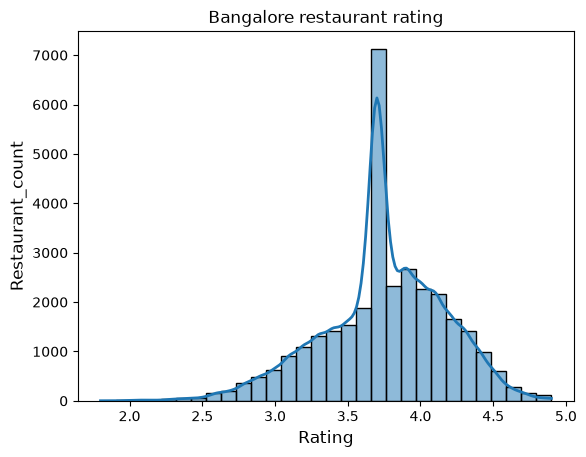

In [70]:
plt.Figure(figsize=(15,6))
sns.histplot(df1['rate'],kde=True,bins=30,line_kws={'color':'r','linewidth':2})
plt.title('Bangalore restaurant rating',fontsize=12)
plt.xlabel('Rating',fontsize=12)
plt.ylabel('Restaurant_count',fontsize=12)
plt.show()

In [71]:
df1.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)'],
      dtype='str')

In [72]:
df1['rate'].skew()
#as per the result the rating is left skewed but it is almost near to zero. 
# also it might have happened due to the way we handled null values,, we filled null with median


np.float64(-0.38319516936440934)

In [73]:
online_order_yes=df1[df1['online_order']=='Yes'].groupby('location')['name'].count()


In [74]:
total_count=df1.groupby('location')['name'].count()


In [75]:
online_pct=(online_order_yes/total_count*100).round(1).sort_values(ascending=False)

In [76]:
online_pct.head(10)

location
Rajarajeshwari Nagar    100.0
Kanakapura Road          89.5
Rammurthy Nagar          84.2
Nagawara                 83.8
Yelahanka                83.3
Kumaraswamy Layout       82.6
Kengeri                  80.0
Jeevan Bhima Nagar       79.8
Uttarahalli              76.9
Yeshwantpur              75.8
Name: name, dtype: float64

In [77]:
# from theabove insight we have a 100% online ordering observd from rajarajeshwari nagar
rest_type=df_rest['rest_type'].value_counts().head(15)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Quick Bites'),
  Text(1, 0, 'Casual Dining'),
  Text(2, 0, 'Cafe'),
  Text(3, 0, 'Delivery'),
  Text(4, 0, 'Dessert Parlor'),
  Text(5, 0, 'Bar'),
  Text(6, 0, 'Bakery'),
  Text(7, 0, 'Takeaway'),
  Text(8, 0, 'Pub'),
  Text(9, 0, 'Beverage Shop'),
  Text(10, 0, 'Food Court'),
  Text(11, 0, 'Lounge'),
  Text(12, 0, 'Sweet Shop'),
  Text(13, 0, 'Microbrewery'),
  Text(14, 0, 'Fine Dining')])

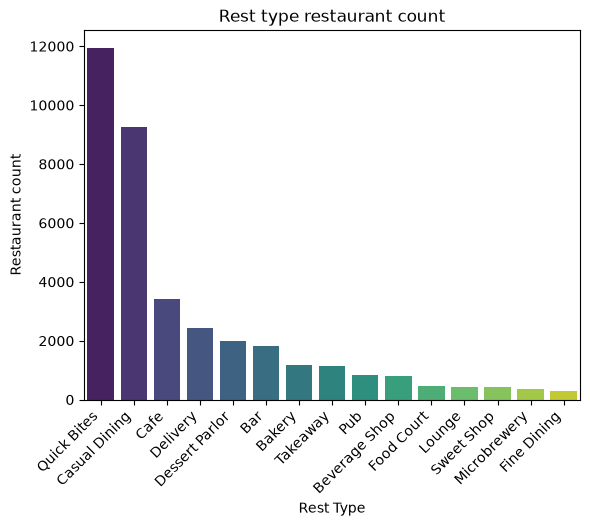

In [78]:
plt.Figure(figsize=(15,6))
sns.barplot(x=rest_type.index,y=rest_type.values,palette='viridis')
plt.title('Rest type restaurant count' ,loc='center')
plt.xlabel('Rest Type')
plt.ylabel('Restaurant count')
plt.xticks(rotation=45,ha='right')


In [79]:
df1.describe().T


,count,mean,std,min,25%,50%,75%,max
rate,31890.0,3.745218,0.418292,1.8,3.5,3.7,4.0,4.9
votes,31890.0,389.229414,978.484158,0.0,11.0,66.0,309.0,16832.0
approx_cost(for two people),31890.0,604.220069,470.008154,40.0,300.0,450.0,750.0,6000.0


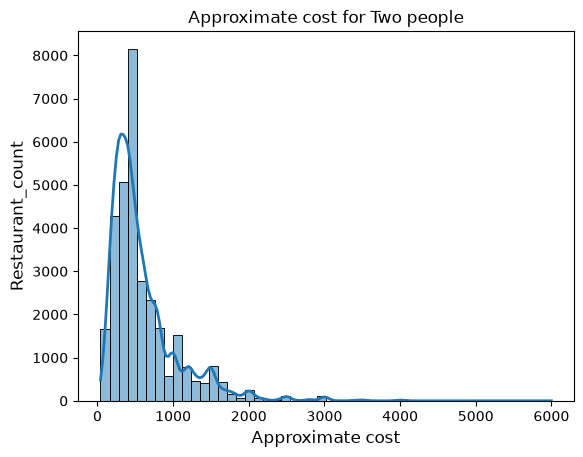

In [80]:
plt.Figure(figsize=(20,6))
sns.histplot(df1['approx_cost(for two people)'],kde=True,bins=50,line_kws={'color': 'red',
              'linewidth': 2})
plt.title('Approximate cost for Two people',fontsize=12)
plt.xlabel('Approximate cost',fontsize=12)
plt.ylabel('Restaurant_count',fontsize=12)
plt.show()


In [81]:
df1['approx_cost(for two people)'].value_counts().head(10)

approx_cost(for two people)
400     4253
300     4086
500     3015
200     2620
600     2315
250     1637
800     1570
700     1261
150     1124
1000    1117
Name: count, dtype: int64

In [82]:
df1['approx_cost(for two people)'].skew()

np.float64(2.3379134152612537)

In [83]:
## from the above insight we can derive that most of the restaurants have the approx.cost for two peole as 400 and 300 
# the histogram is right skewed it might be the case that some high priced restauurants are pulling the graph to right skewed.
# Approx cost for two in premium restaurants are causing this skewness.

#Most Bangalore restaurants priced 300-400 (budget segment),Premium segment (2000+) is underrepresented — aligns with
# Fine Dining gap (0.8% of listings).
# BD team can pursue either:
# → Volume strategy: budget restaurants will reach more customers, lower order value
# → Revenue strategy: premium onboarding higher order per value
 #  in prime locations -- both works
 # depends on the BD team strategy how they want to proceed

In [84]:
#listed_in how the restaurants are listed in Zomato
listed_as=df1['listed_in(type)'].value_counts()

In [85]:
(df1['listed_in(type)'].value_counts()/df1['listed_in(type)'].count()*100).round(1)

listed_in(type)
Delivery              45.7
Dine-out              37.1
Desserts               7.1
Cafes                  3.7
Drinks & nightlife     2.7
Buffet                 2.0
Pubs and bars          1.8
Name: count, dtype: float64

In [86]:
#from above findings, we can say that 45.7% restaurants are listed under delivey. restaurants listed under delivery 
# must accept and deliver the orders

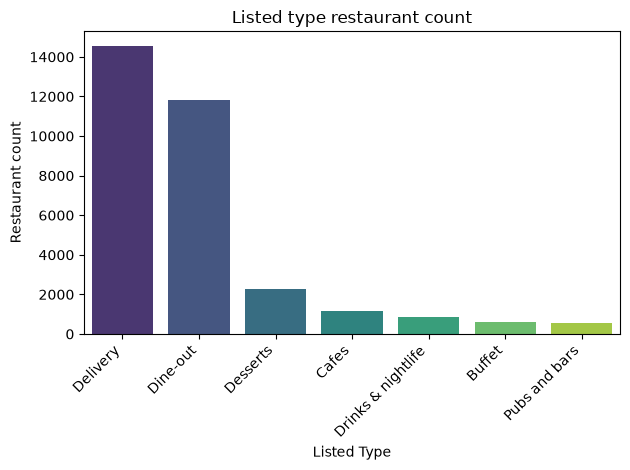

In [87]:
plt.Figure(figsize=(15,6))
sns.barplot(x=listed_as.index,y=listed_as.values,palette='viridis')
plt.title('Listed type restaurant count' ,loc='center')
plt.xlabel('Listed Type')
plt.ylabel('Restaurant count')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [88]:
cuisine_top_20=df_cuisine['cuisines'].value_counts().head(20)

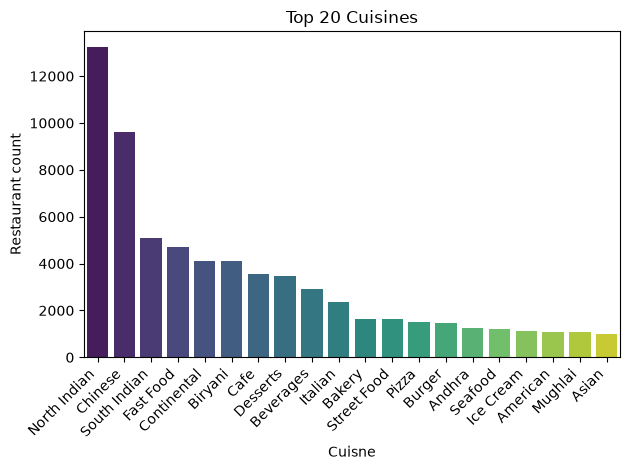

In [89]:
plt.Figure(figsize=(15,6))
sns.barplot(x=cuisine_top_20.index,y=cuisine_top_20.values,palette='viridis')
plt.title('Top 20 Cuisines' ,loc='center')
plt.xlabel('Cuisne')
plt.ylabel('Restaurant count')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [90]:
#North Indian is the top cuisine in the entire city

Bivariate Analysis

In [91]:
df1.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)'],
      dtype='str')

In [92]:
#Location wise restautant count, demand, average ratings,supply 

metrics=df1.groupby('location').agg({'name':'count','votes':'mean','rate':'mean'}).reset_index()

In [93]:
metrics

,location,name,votes,rate
0,BTM,2089,186.860699,3.661465
1,Banashankari,559,192.998211,3.676386
2,Banaswadi,406,60.751232,3.562315
3,Bannerghatta Road,1024,176.538086,3.575098
4,Basavanagudi,433,150.122402,3.680370
...,...,...,...,...
86,West Bangalore,6,185.000000,3.533333
87,Whitefield,2013,233.879285,3.656085
88,Wilson Garden,109,32.559633,3.567890
89,Yelahanka,6,31.500000,3.650000


In [94]:
metrics.rename(columns={'name':'restuarant_count'},inplace=True)

In [95]:
metrics['votes']=metrics['votes'].round()
metrics['rate']=metrics['rate'].round(1)

In [96]:
metrics

,location,restuarant_count,votes,rate
0,BTM,2089,187.0,3.7
1,Banashankari,559,193.0,3.7
2,Banaswadi,406,61.0,3.6
3,Bannerghatta Road,1024,177.0,3.6
4,Basavanagudi,433,150.0,3.7
...,...,...,...,...
86,West Bangalore,6,185.0,3.5
87,Whitefield,2013,234.0,3.7
88,Wilson Garden,109,33.0,3.6
89,Yelahanka,6,32.0,3.6


In [97]:
#Most of the location rating is between 3.5 to 3.7 this is because 24% of the date is 
#being filled with median value while handling null values


In [98]:
metrics['demand_supply']=(metrics.votes/metrics.restuarant_count).round(2)

In [99]:
print(metrics.describe().T)

                  count        mean         std  min    25%    50%     75%  \
restuarant_count   91.0  350.439560  472.946819  1.0  41.00  132.0  477.00   
votes              91.0  257.670330  302.198686  0.0  58.00  171.0  285.00   
rate               91.0    3.696703    0.187053  3.2   3.60    3.7    3.80   
demand_supply      91.0    4.771099   19.907758  0.0   0.42    0.9    2.36   

                     max  
restuarant_count  2089.0  
votes             1358.0  
rate                 4.2  
demand_supply      183.0  


In [100]:
metrics.isna().sum()

location            0
restuarant_count    0
votes               0
rate                0
demand_supply       0
dtype: int64

#Here we are filtering the restaurants based on some threshold because the demand supply ratio will get impacted because of some location
where the supply is less but demand is high(avg voting is high) it might cause because of some viral restaurant. also we are setting it to 100 because we donot want to loose some ocation where there is  low supply and demand and there is an opportunity to onboard the restaurant 

In [101]:
threshold=100
metrics_filtered=metrics[metrics['restuarant_count']>100].reset_index()

In [102]:
len(metrics)

91

In [103]:
len(metrics_filtered)

53

In [104]:
metrics_filtered.drop(columns=['index'],inplace=True)

Sorting it based on the demand supply ratio

In [105]:
sorted_by_demand_supply=metrics_filtered.sort_values(by='demand_supply',ascending=False).head(10)

In [106]:
sorted_by_demand_supply.reset_index(drop=True)

,location,restuarant_count,votes,rate,demand_supply
0,Koramangala 3rd Block,107,728.0,4.1,6.80
1,St. Marks Road,228,1081.0,4.1,4.74
2,Cunningham Road,256,962.0,4.0,3.76
3,Lavelle Road,379,1190.0,4.2,3.14
4,Church Street,434,1275.0,4.1,2.94
5,Koramangala 4th Block,519,1118.0,4.0,2.15
6,Residency Road,378,647.0,4.0,1.71
7,Koramangala 7th Block,511,758.0,4.0,1.48
8,MG Road,527,689.0,4.0,1.31
9,Koramangala 6th Block,510,605.0,3.9,1.19


From the above result we can say that the deamnd supply ratio is high in Koramangala 3rd block,st.marks road and cunninghan road,
Here the supply is low but demand is high, high quality area. so  we can see there is a gap. BD team can think about onboarding restaurant from this location.
These locations show high customer demand relative to available supply, indicating unmet market opportunity for Zomato restaurant partnerships.

In [107]:
#Find the top cuisines in the top 10 locations with highest demand_supply ratio.
top_10_locations=sorted_by_demand_supply['location'].to_list()

In [108]:
top_10_locations

['Koramangala 3rd Block',
 'St. Marks Road',
 'Cunningham Road',
 'Lavelle Road',
 'Church Street',
 'Koramangala 4th Block',
 'Residency Road',
 'Koramangala 7th Block',
 'MG Road',
 'Koramangala 6th Block']

In [109]:
df_cuisine_filtered=df_cuisine[df_cuisine['location'].isin(top_10_locations)].reset_index(drop=True)

In [110]:
df_cuisine_filtered.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
0,Cafe Noir,Yes,No,3.7,0,Koramangala 7th Block,Casual Dining,European,1500,Delivery
1,Cafe Noir,Yes,No,3.7,0,Koramangala 7th Block,Casual Dining,French,1500,Delivery
2,Cafe Noir,Yes,No,3.7,0,Koramangala 7th Block,Casual Dining,Salad,1500,Delivery
3,Bhandary's Kitchen,Yes,No,3.6,16,Koramangala 7th Block,Delivery,North Indian,300,Delivery
4,Cool Bites,Yes,No,3.7,0,Koramangala 4th Block,Quick Bites,Fast Food,200,Delivery


In [111]:
top_10_cuisine=df_cuisine_filtered['cuisines'].value_counts().head(10).reset_index()
cuisine_list=top_10_cuisine['cuisines'].tolist()

In [112]:
cuisine_list

['North Indian',
 'Chinese',
 'Continental',
 'Cafe',
 'Italian',
 'Desserts',
 'Pizza',
 'Fast Food',
 'South Indian',
 'American']

In [113]:
df_cuisine_filtered=df_cuisine_filtered[df_cuisine_filtered['cuisines'].isin(cuisine_list)]

In [114]:
df_cuisine_filtered

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type)
3,Bhandary's Kitchen,Yes,No,3.6,16,Koramangala 7th Block,Delivery,North Indian,300,Delivery
4,Cool Bites,Yes,No,3.7,0,Koramangala 4th Block,Quick Bites,Fast Food,200,Delivery
6,Ebony,Yes,Yes,4.3,3126,MG Road,Casual Dining,North Indian,1500,Buffet
7,Ebony,Yes,Yes,4.3,3126,MG Road,Casual Dining,South Indian,1500,Buffet
8,JW Kitchen - JW Marriott Bengaluru,No,Yes,4.4,2111,Lavelle Road,Fine Dining,North Indian,2200,Buffet
...,...,...,...,...,...,...,...,...,...,...
10897,White Plate,No,Yes,4.2,264,MG Road,"Casual Dining, Bar",North Indian,1500,Drinks & nightlife
10898,Hammered,Yes,Yes,4.7,4845,Cunningham Road,"Pub, Cafe",North Indian,1300,Drinks & nightlife
10901,Hammered,Yes,Yes,4.7,4845,Cunningham Road,"Pub, Cafe",Continental,1300,Drinks & nightlife
10902,Hammered,Yes,Yes,4.7,4845,Cunningham Road,"Pub, Cafe",Cafe,1300,Drinks & nightlife


In [115]:
location_cuisine=df_cuisine_filtered.groupby(['location','cuisines'])['name'].count().reset_index()

In [116]:
location_cuisine

,location,cuisines,name
0,Church Street,American,97
1,Church Street,Cafe,111
2,Church Street,Chinese,85
3,Church Street,Continental,133
4,Church Street,Desserts,42
...,...,...,...
93,St. Marks Road,Desserts,16
94,St. Marks Road,Fast Food,40
95,St. Marks Road,Italian,19
96,St. Marks Road,North Indian,75


In [117]:
pivot_table=location_cuisine.pivot_table(index='location',columns='cuisines',values='name',aggfunc='sum').fillna(0)

In [118]:
pivot_table

cuisines,American,Cafe,Chinese,Continental,Desserts,Fast Food,Italian,North Indian,Pizza,South Indian
location,,,,,,,,,,
Church Street,97.0,111.0,85.0,133.0,42.0,30.0,65.0,118.0,33.0,34.0
Cunningham Road,4.0,87.0,83.0,83.0,45.0,26.0,30.0,121.0,12.0,45.0
Koramangala 3rd Block,13.0,57.0,27.0,33.0,3.0,3.0,18.0,35.0,0.0,4.0
Koramangala 4th Block,42.0,111.0,147.0,134.0,91.0,27.0,129.0,171.0,117.0,52.0
Koramangala 6th Block,29.0,71.0,139.0,98.0,71.0,81.0,58.0,198.0,90.0,53.0
Koramangala 7th Block,45.0,56.0,122.0,50.0,80.0,53.0,48.0,170.0,36.0,26.0
Lavelle Road,6.0,47.0,43.0,119.0,67.0,4.0,128.0,107.0,29.0,14.0
MG Road,29.0,139.0,125.0,165.0,63.0,53.0,82.0,183.0,50.0,38.0
Residency Road,6.0,46.0,107.0,59.0,58.0,52.0,33.0,115.0,19.0,31.0


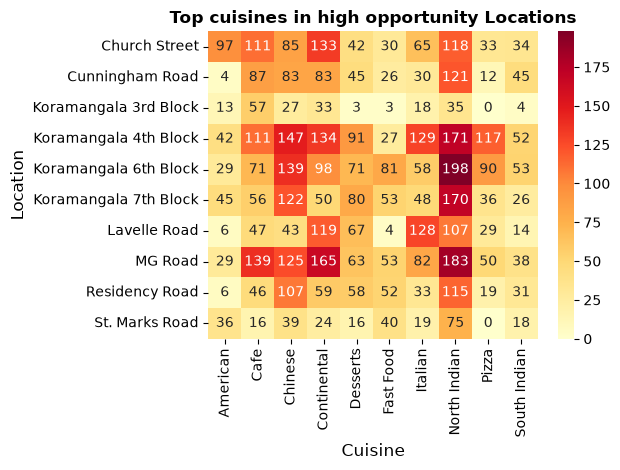

In [119]:
plt.Figure(figsize=(15,6))
sns.heatmap(pivot_table,annot=True,cmap='YlOrRd',fmt='.0f')
plt.xlabel('Cuisine',fontsize=12)
plt.ylabel('Location',fontsize=12)
plt.title('Top cuisines in high opportunity Locations',fontweight='bold',loc='center',fontsize=12)
plt.tight_layout()
plt.show()

we plot the above heat map against the top 10 cuisines in the top 10 high opportunity locations. from this we can infer that North indian is top cuisine
top 3 locations with high demand-supply are:
1. Koramangala 3rd Block has zero pizza restaurants despite being a high demand-supply opportunity area. Onboarding pizza restaurants here could capture unmet demand.
Koramangala 3rd Block and St. Marks Road
are the STRONGEST BD opportunities because:

1. High demand-supply ratio
   (6.80 and 4.74 respectively)

2. Low supply across ALL cuisine types
   not just one specific cuisine

3. Pizza specifically = 0 in both
   → Immediate onboarding target

4. High ratings (4.1 and 4.1)
   → Quality conscious customer base
   → Premium restaurant opportunity

In [120]:
df1_filtered=df1[df1['location'].isin(top_10_locations)]

In [121]:
approx_cost=df1_filtered.groupby('location')['approx_cost(for two people)'].agg('mean').round().reset_index()

In [122]:
approx_cost=approx_cost.sort_values(by='approx_cost(for two people)',ascending=False).reset_index(drop=True)

<Axes: ylabel='Count'>

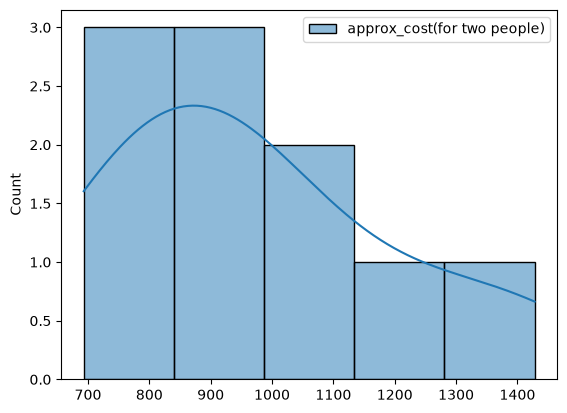

In [123]:
sns.histplot(approx_cost,kde=True)

In [124]:
approx_cost['approx_cost(for two people)'].skew()

np.float64(0.8598601622781699)

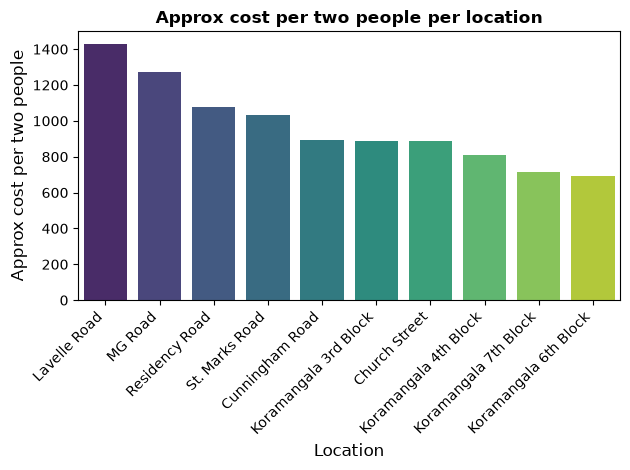

In [125]:
plt.Figure(figsize=(15,6))
sns.barplot(approx_cost,x='location',y='approx_cost(for two people)',palette='viridis')
plt.title('Approx cost per two people per location',fontsize=12,fontweight='bold')
plt.xlabel('Location',fontsize=12)
plt.ylabel('Approx cost per two people',fontsize=12)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

Final Recommendations: 
Recommendation 1 — Location: Finding: Koramangala 3rd Block,St. Marks Road are the top two locations where the demand and supply
ratio is high. There is less supply but high demand is observed in those areas 
Action: BD Team can consider these locations for new restaurant onboarding
Evidence: 
Koramangala 3rd Block: 
    Demand-Supply ratio = 6.80 
    Restaurants = 107 (low supply) 
    Avg votes = 728 (high demand) 
    Avg rating = 4.1 (quality area) 
St.Marks Road: 
    Demand-Supply ratio = 4.74 
    Restaurants = 228 
    Avg votes = 1,081 
    Avg rating = 4.1

Recommendation 2 — Cuisine: 
Finding: There are no Pizza outlets from Koramangala 3rd block and St.marks Road. Pizza ranks 13th overall in Bangalore with
1,506 restaurants citywide — proving customer demand exists. Yet supply = 0 in both top opportunity locations. 
Action: There is an opportunity to onboard any pizza outlets from these locations 
Evidence: Koramagala 3rd block -0.0 Pizza St.marks Road-0.0 Pizza

Recommendation 3 — Restaurant Type + Location: 
Finding: From the approximate cost analysis we observed that Koramangala 3rd Block has avg cost 890 which tells it is a mid-premium segment,Lavelle road has high avg cost for two people it is a premium segment. 
Action: BD team can target Koramangala 3rd block for casual dining and cafes, whereas lavelle Road for Premium fine dining. 
Evidence: 
location approx_cost(for two people) 
0 Lavelle Road 1428.0 
1 MG Road 1274.0 
2 Residency Road 1080.0 
3 St. Marks Road 1032.0 
4 Cunningham Road 892.0 
5 Koramangala 3rd Block 890.0 
6 Church Street 889.0 
7 Koramangala 4th Block 811.0 
8 Koramangala 7th Block 717.0 
9 Koramangala 6th Block 693.0

In [126]:
##T test
# Do restaurants with online ordering  have significantly higher ratings than those without?
#H0: online ordering doen't affect the ratings
#H1: Online orders affect the rating


In [127]:
df_group1=df1[df1['online_order']=='Yes']['rate']

In [128]:
df_group2=df1[df1['online_order']=='No']['rate']

In [129]:
print(f"online yes: n={len(df_group1)} , mean={df_group1.mean():.2f}")
print(f"online No: n={len(df_group2)} , mean={df_group2.mean():.2f}")
print(f"group mean difference {df_group1.mean()-df_group2.mean():.2f}")

online yes: n=19169 , mean=3.76
online No: n=12721 , mean=3.72
group mean difference 0.04


In [130]:
from scipy import stats

In [131]:
tstat,pvalue=stats.ttest_ind(df_group1,df_group2)

In [132]:
print(f'TStatistics= {tstat:.4f}')
print(f"pvalue= {pvalue:.4f}")
if pvalue <0.05:
    print("reject Null hypothesis")
else:
    print("Failed to reject Null Hypothesis")

TStatistics= 8.3507
pvalue= 0.0000
reject Null hypothesis


pvlaue is almost zero which is highly significant that we reject the null hypothesis.
Online ordering significantly affect the restaurant ratings.            
Recommendation:                                                                                                                                               BDA team should prioritize onboarding the restuarant that accepts online ordering.

In [133]:
# T-Test: Online Ordering vs Rating
# H0: Online ordering has no effect on rating
# H1: Online ordering restaurants rate higher

# Result:
# T-statistic = 8.35
# p-value = 0.0000 (extremely significant)
# Decision: Reject H0

# Finding:
# Restaurants with online ordering have significantly higher ratings than those without (p ≈ 0.0000)

# Finding 4 — Online Ordering: 
#   Statistical finding: Restaurants with online ordering rate significantly higher (3.76 vs 3.72, p ≈ 0.0000, T = 8.35)
# However practical difference is marginal(0.04 on a 5-point scale).
# 
# Advisory: BD team may prefer onboarding restaurants that accept online ordering as they show slightly higher ratings —
# but this should not be a mandatory criteria for onboarding decisions.  
# Location and cuisine gap should remain the primary selection criteria.

In [134]:
df1.to_csv('Zomato_clean_data.csv',index=False)

PermissionError: [Errno 13] Permission denied: 'Zomato_clean_data.csv'

In [ ]:
metrics_filtered.to_csv('Zomato_location_metrics.csv',index=False)

In [ ]:
df_cuisine_filtered.to_csv('Zomato_cuisine_filtered.csv',index=False)

In [ ]:
df_rest['rest_type'].value_counts().head(20).reset_index().to_csv('Zomato_rest_type.csv',index=False)

In [135]:
approx_cost.to_csv(
    'zomato_cost_location.csv',
    index=False)
